# Some issues and strange places in `TensorFlow`'s official document "Introduction to gradients and automatic differentiation"

I've learnt a lot of `TensorFlow` from the official documentation. I appreciate the official documents helping me solve many problems in my project.

There are some issues and strange places when I am reading the official document "[Introduction to gradients and automatic differentiation](https://www.tensorflow.org/guide/autodiff)".

This is a brief report. I wish we could make the document better and benefit readers / researchers / engineers.


Date: 2026-04-08

## 1. Setup

In [3]:
import tensorflow as tf

## 2. Issues, strange places, and suggestions

### 2.1. Better example code for the subsection "1. Replaced a variable with a tensor"

**Position:** "1. Replaced a variable with a tensor" subsection

**Link:** https://www.tensorflow.org/guide/autodiff#1_replaced_a_variable_with_a_tensor

**Condition:** The original example is very concise. However, it took me a considerable amount of time to modify the code and test it to understand the example fully. 

I think there are two points that confused me.  
Point 1: The derivative of `y = x + 1` is a constant scalar `1`. This will cause no value change as the number of epoch increases. We can't obviously see the change in the value.  
Point 2: The comment directly gives the correct code `# This should be x.assign_add(1)` without the reason.

**Suggestion:** I have modified the example code as shown below.  
1. The formula has been changed from `y = x + 1` to `y = x**2`. The derivative is now `2x`, and we can obviously see the value change corresponding to epoch. 
2. A comment "The `tf.Variable` has been inadvertently replaced with a `tf.Tensor`." has been added.
3. A epoch indicator is added. `print("epoch:", epoch)`
4. The number of epoch is changed from 2 to 3.

The suggested example code:

In [7]:
x = tf.Variable(2.0)

for epoch in range(3):
    with tf.GradientTape() as tape:
        y = x**2

    print("epoch:", epoch)
    print(type(x).__name__, ":", tape.gradient(y, x))
    x = x + 1    # The `tf.Variable` has been inadvertently replaced with a `tf.Tensor`. 
                 # This should be `x.assign_add(1)`

epoch: 0
ResourceVariable : tf.Tensor(4.0, shape=(), dtype=float32)
epoch: 1
EagerTensor : None
epoch: 2
EagerTensor : None


Test suggested example code with `x.assign_add(1.0)`:

In [9]:
x = tf.Variable(2.0)

for epoch in range(3):
    with tf.GradientTape() as tape:
        y = x**2

    print("epoch:", epoch)
    print(type(x).__name__, ":", tape.gradient(y, x))
    x.assign_add(1.0)

epoch: 0
ResourceVariable : tf.Tensor(4.0, shape=(), dtype=float32)
epoch: 1
ResourceVariable : tf.Tensor(6.0, shape=(), dtype=float32)
epoch: 2
ResourceVariable : tf.Tensor(8.0, shape=(), dtype=float32)


Original example code:

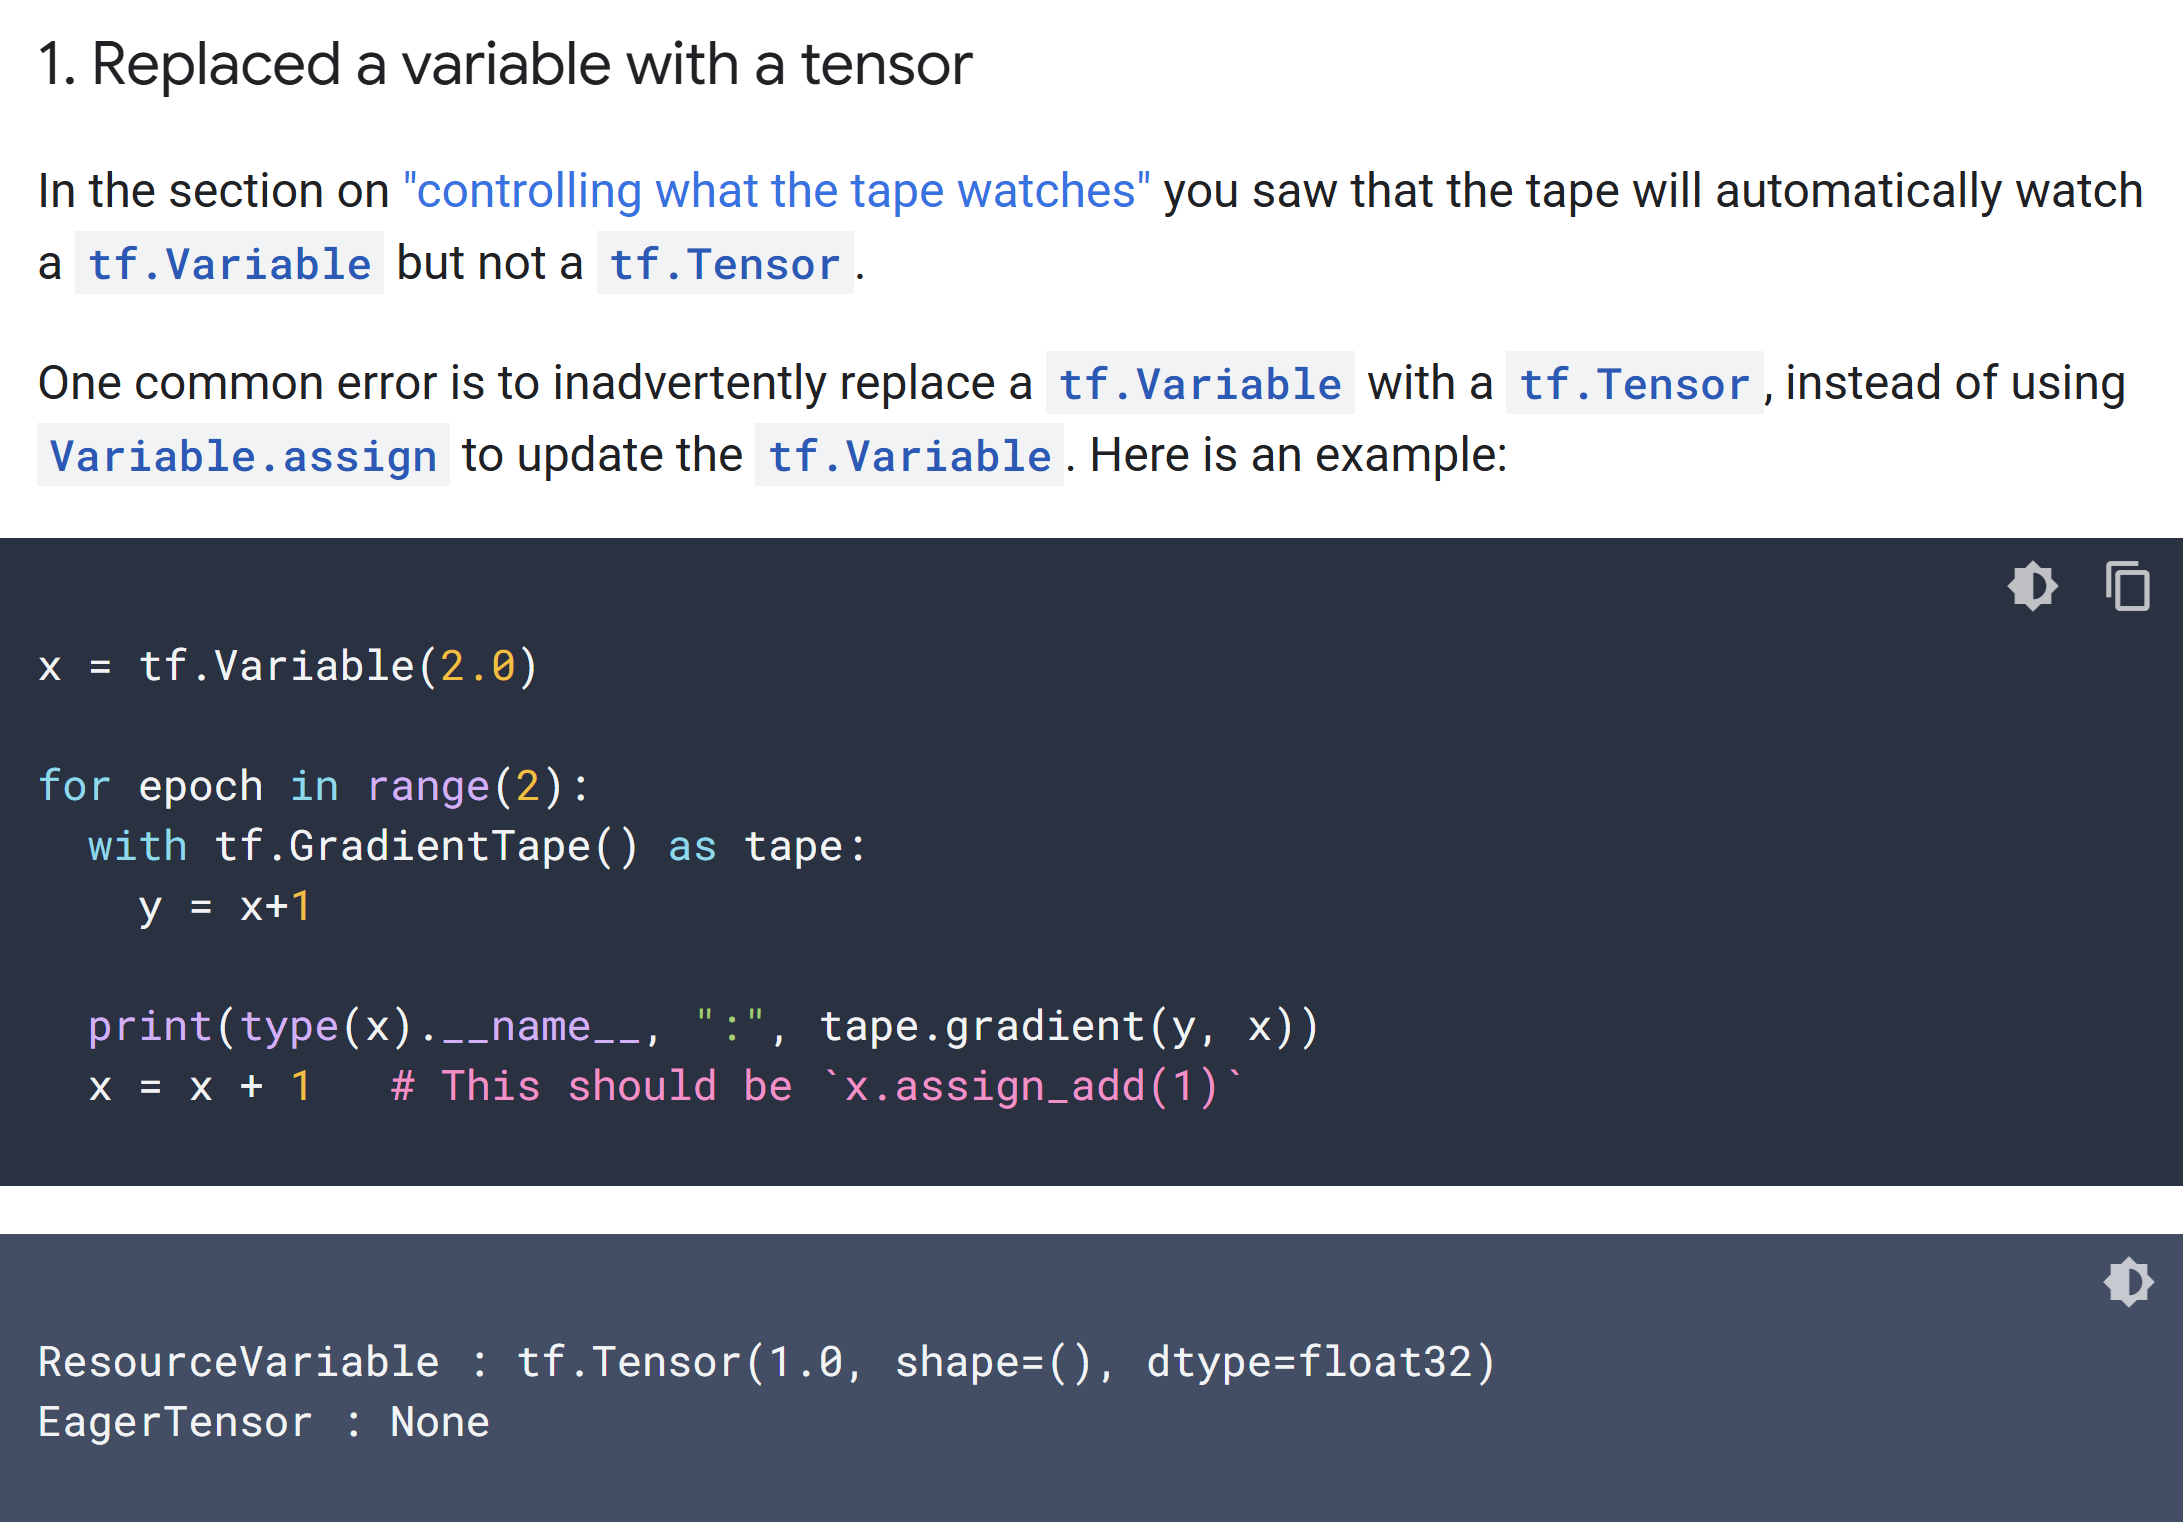

### 2.2. Format consistency issue

**Position:** "Computing gradients" section

**Link:** https://www.tensorflow.org/guide/autodiff#computing_gradients

**Condition:** There is a format issue in the "*forward* pass" and "*backward pass*", as shown in the red rectangles in the following image.

Readers might confuse the whole termiology.

**Suggestion:** It seems that "*forward pass*" and "*backward pass*" are more reasonable.

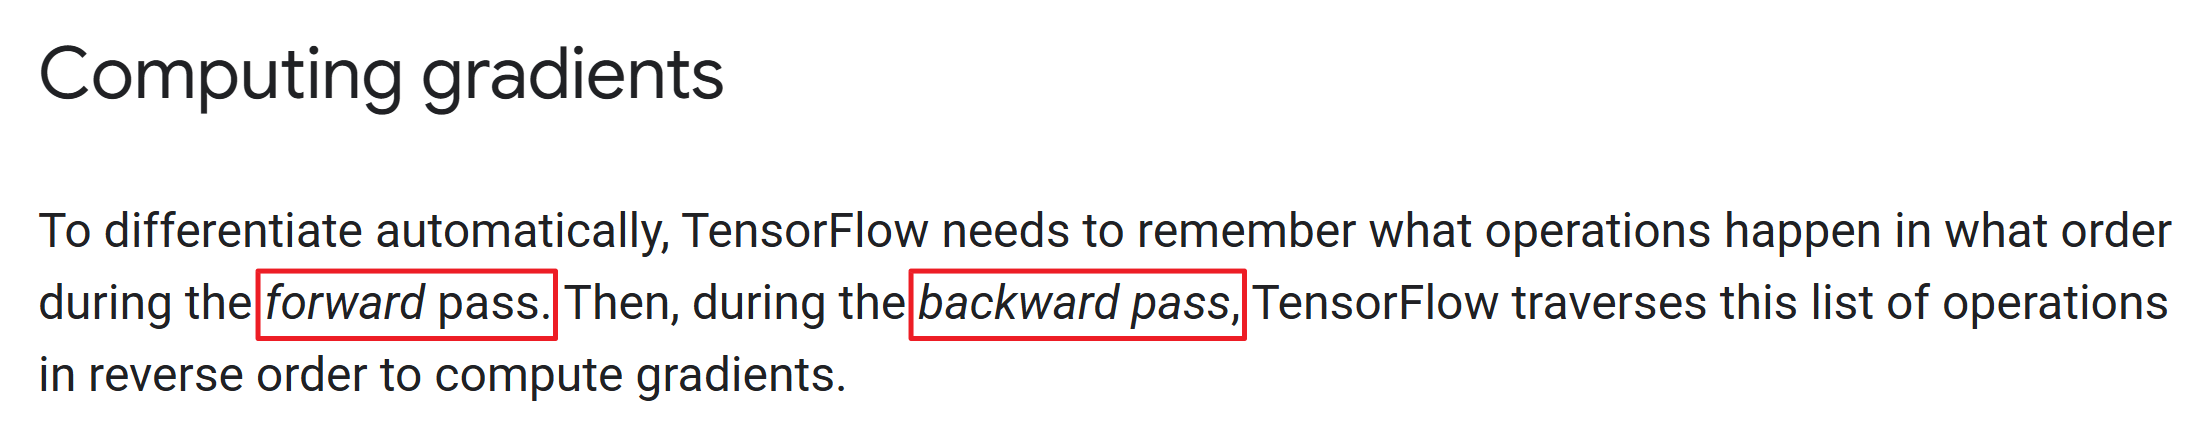

### 2.3. Better comment suggestion 

**Position:** "Gradient tapes" section

**Link:** https://www.tensorflow.org/guide/autodiff#gradient_tapes

**Condition:**
It's better to use "`# dy/dx = 2x`" instead of "`# dy = 2x * dx`" in the comment. (See the figure below)

I know that the "dy/dx = 2x" and "dy = 2x * dx" are equivalent. 

As this is the first time I see the comment "`# dy = 2x * dx`" and the following code "`dy_dx = tape.gradient(y, x)`", I don't get the meaning immediately. 

When I changed the comment to "`# dy/dx = 2x`", which is much closer to the code "`dy_dx = tape.gradient(y, x)`". And I can obviously understand the code.

**Suggestion:** Use "`# dy/dx = 2x`" instead of "`# dy = 2x * dx`" in the comment.

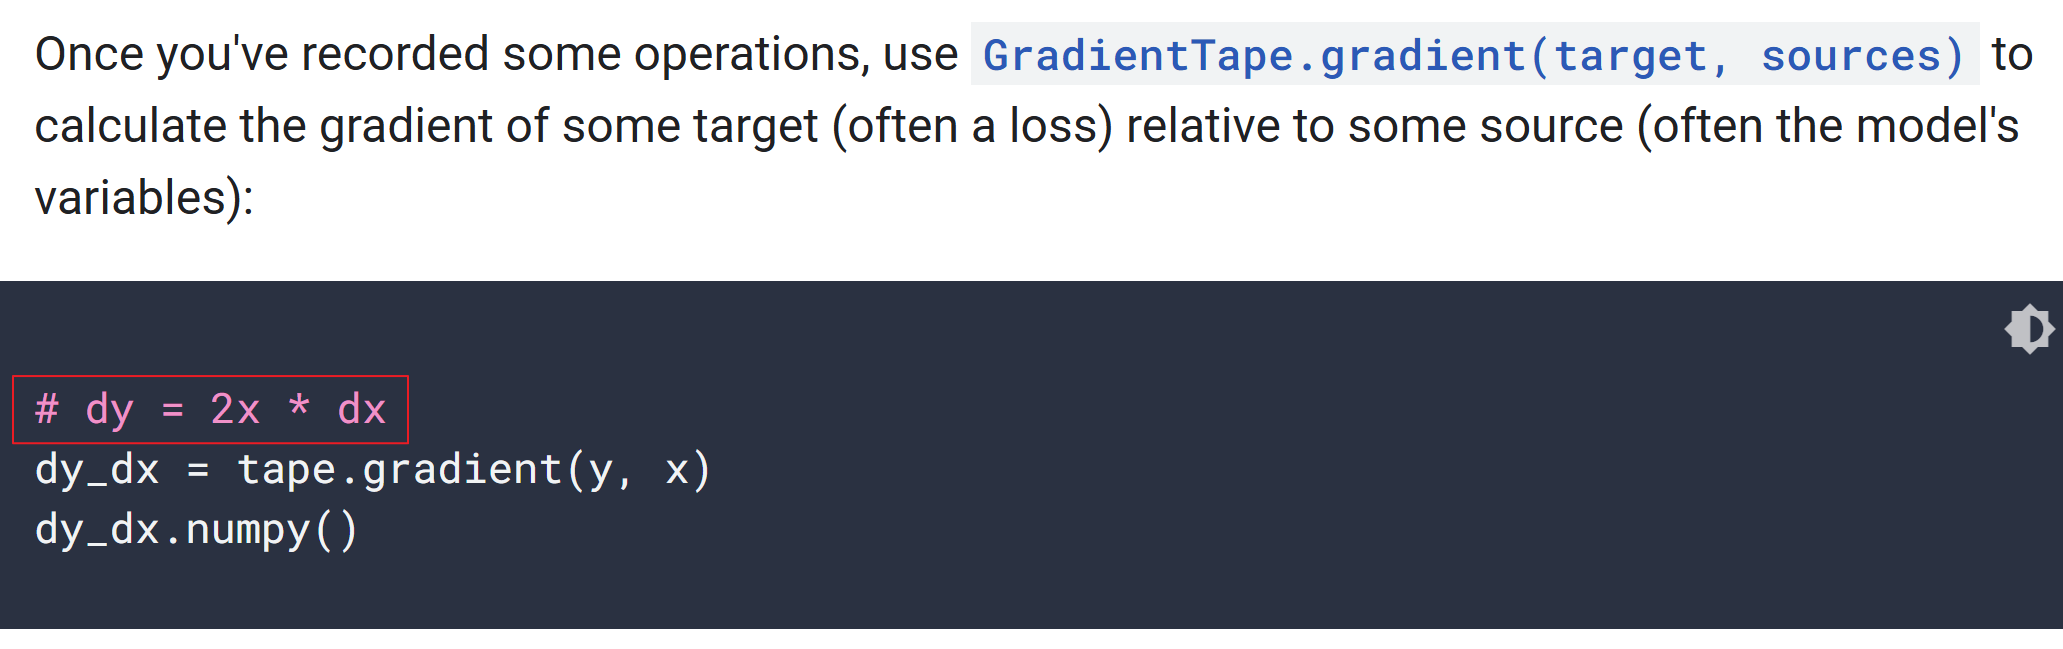

The same thing happened again in the "Controlling what the tape watches" section. (See the figure below)

Link: https://www.tensorflow.org/guide/autodiff#controlling_what_the_tape_watches

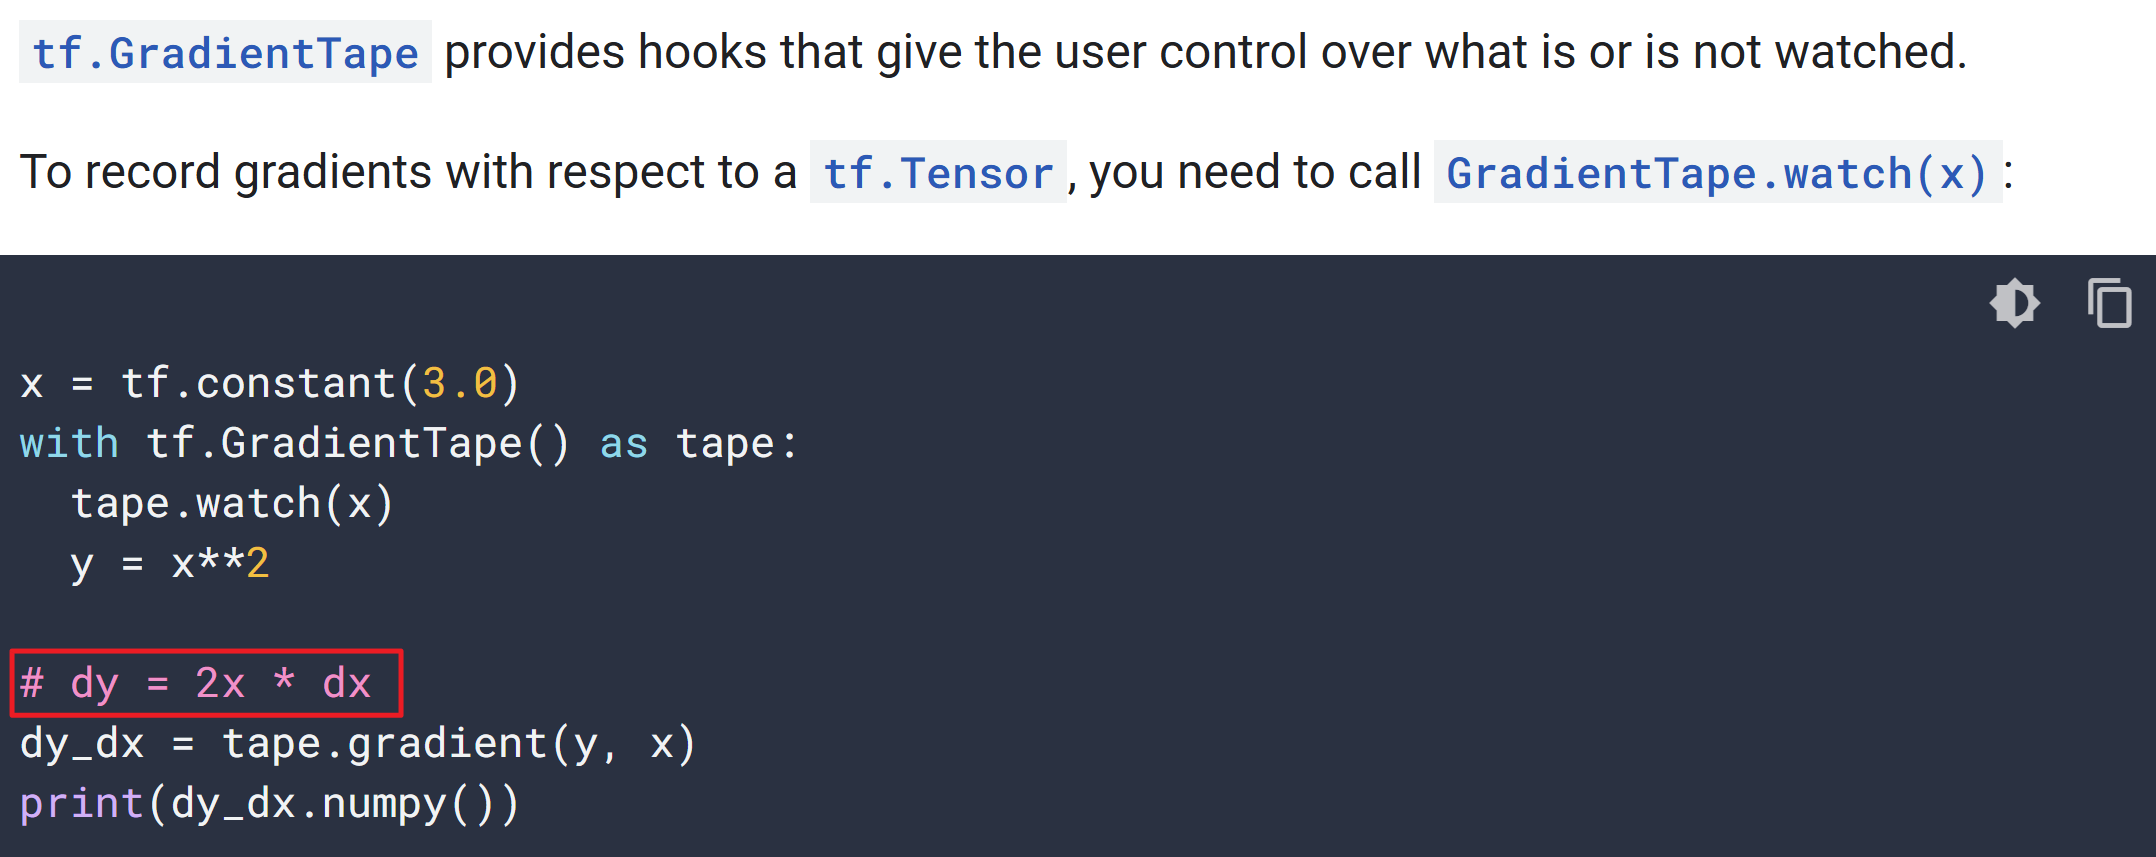